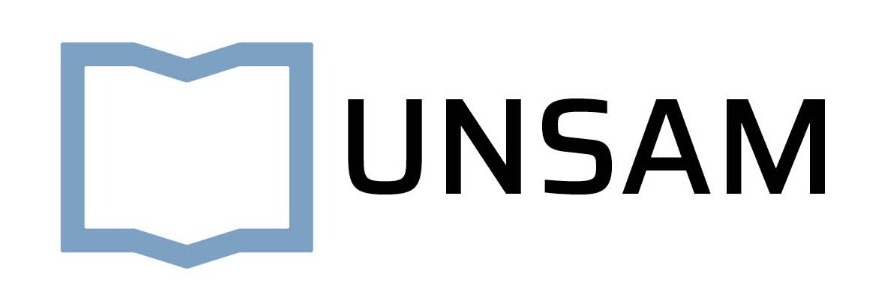

#### Análisis y Procesamiento de Señales

# TS1: Síntesis y operaciones de señales
#### Alumno: Sebastián Roca Garza



## Introducción
**Este informe tiene como objetivo la síntesis de diversas señales (determinísticas y estocásticas) y el análisis de su contenido espectral. A través de Python, se generarán señales sinusoidales, secuencias de ruido (distribución normal y uniforme) y pulsos rectangulares.** 

**Para cada una de estas señales, se evaluará su comportamiento en el dominio de la frecuencia mediante el cálculo y la visualización del módulo $|X[k]|$ de la Transformada Discreta de Fourier (DFT). Se utilizará una longitud fija de $N = 1000$ muestras para todos los casos.**

# Codigo y Análisis


## Definicón de funciones y parámetros

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


# Parámetros fijos

N = 1000       # Muestras
f = 2000       # Frecuencia de la señal (Hz)
fs = 20000     # Frecuencia de muestreo (Hz)
dc = 0         # Componente de continua


# Frecuencia digital w0 (radianes por muestra)
w0 = 2 * np.pi * (f / fs)  # 0.2 * pi -> 10 puntos por período


n = np.arange(0, N, 1) # Vector de muestras 


freqs = (n[:N//2] * fs) / N # Es mi eje x, osea para que este en valores de frecuencia y no de mis indices "k" (o bins); y va hasta N/2 por el Teorema de Nyquist

#Función Generadora de Sinusoidales 
def mi_funcion_sen(vmax=1, dc=dc, w=w0, ph=0, nn=N):
    n_vector = np.arange(0, nn, 1)
    x = vmax * np.sin(w * n_vector + ph) + dc
    
    return n_vector, x

## Primera Señal: $x_1[n]$ (Sinusoidal pura)

Sintetizamos una señal de $2\text{ kHz}$. Asumiendo una potencia media de $1\text{ W}$, la amplitud debe ser $V_{max} = \sqrt{2\text{W}} \approx 1.414\text{ V}$.

La resolución espectral que es:
$$\Delta f = \frac{f_s}{N} = \frac{20000\text{ Hz}}{1000} = 20\text{ Hz/bin}$$

Dado que la frecuencia es $2000\text{ Hz}$, esperamos ver toda la energía concentrada en el índice $k = \frac{2000}{20} = 100$.

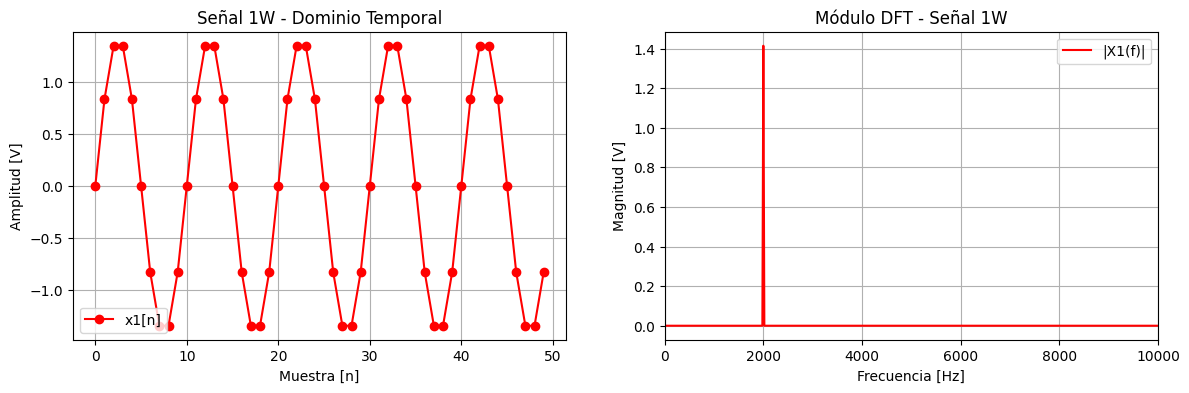

In [3]:
vmax_1 = np.sqrt(2) 
nn_1, x1 = mi_funcion_sen(vmax=vmax_1, ph=0)

# Transformada (DFT) normalizada y recortada al espectro positivo
fft_x1 = (2 / N) * np.fft.fft(x1)
mod_x1 = np.abs(fft_x1)[:N//2]

# Gráficos Señal 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(nn_1[:50], x1[:50], marker='o', color='red', label='x1[n]')
ax1.set_title('Señal 1W - Dominio Temporal')
ax1.set_xlabel('Muestra [n]')
ax1.set_ylabel('Amplitud [V]')
ax1.grid()
ax1.legend()

ax2.plot(freqs, mod_x1, color='red', label='|X1(f)|')
ax2.set_title('Módulo DFT - Señal 1W')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud [V]')
ax2.grid(); ax2.set_xlim(0, 10000); ax2.legend()
plt.show()

##  Segunda Señal: $x_2[n]$ (Sinusoidal de 2W, desfasada $\frac{\pi}{2}$)

Para esta señal piden una potencia de $2\text{ W}$ y un desfasaje de $\frac{\pi}{2}$.
$$V_{max} = \sqrt{2 \cdot 2\text{W}} = 2\text{ V}$$
El desfasaje en el dominio temporal modifica únicamente la fase de la señal pero **no altera el módulo** de su Transformada, por lo que se mantendra el pico en $2000\text{ Hz}$ pero con una amplitud de $2\text{ V}$.

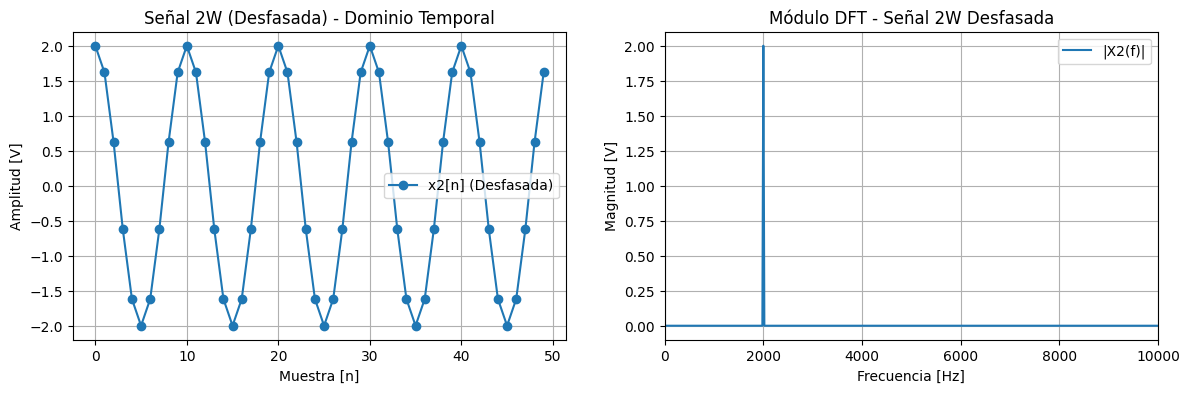

In [4]:
vmax_2 = np.sqrt(2 * 2) 
fase_2 = np.pi / 2
nn_2, x2 = mi_funcion_sen(vmax=vmax_2, ph=fase_2)

fft_x2 = (2 / N) * np.fft.fft(x2)
mod_x2 = np.abs(fft_x2)[:N//2]

# Gráficos Señal 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(nn_2[:50], x2[:50], marker='o', label='x2[n] (Desfasada)')
ax1.set_title('Señal 2W (Desfasada) - Dominio Temporal')
ax1.set_xlabel('Muestra [n]')
ax1.set_ylabel('Amplitud [V]')
ax1.grid(); ax1.legend()

ax2.plot(freqs, mod_x2, label='|X2(f)|')
ax2.set_title('Módulo DFT - Señal 2W Desfasada')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud [V]')
ax2.grid(); ax2.set_xlim(0, 10000); ax2.legend()
plt.show()

## 4. Señales Estocásticas: Ruido Normal y Uniforme

Para las señales de ruido, la potencia media de una señal sin componente de continua ($DC = 0$) es exactamente igual a su varianza ($\sigma^2$). Dado que nos piden $0.1\text{ W}$, la varianza debe ser $0.1$.

**Ruido de Distribución Normal (Gaussiana):**
La desviación estándar es $\sigma = \sqrt{\text{Varianza}} = \sqrt{0.1}$.

**Ruido de Distribución Uniforme:**
Para una variable uniforme centrada en cero, distribuida entre $[-a, a]$, su varianza es $\sigma^2 = \frac{a^2}{3}$.
Igualando a nuestra potencia:
$$\frac{a^2}{3} = 0.1 \implies a^2 = 0.3 \implies a = \sqrt{0.3}$$
Por ende, los límites de la distribución serán $[-\sqrt{0.3}, \sqrt{0.3}]$.

A diferencia de las sinusoides, el espectro de estos ruidos no tendrá un pico único, sino que la energía estará dispersa por todas las frecuencias.

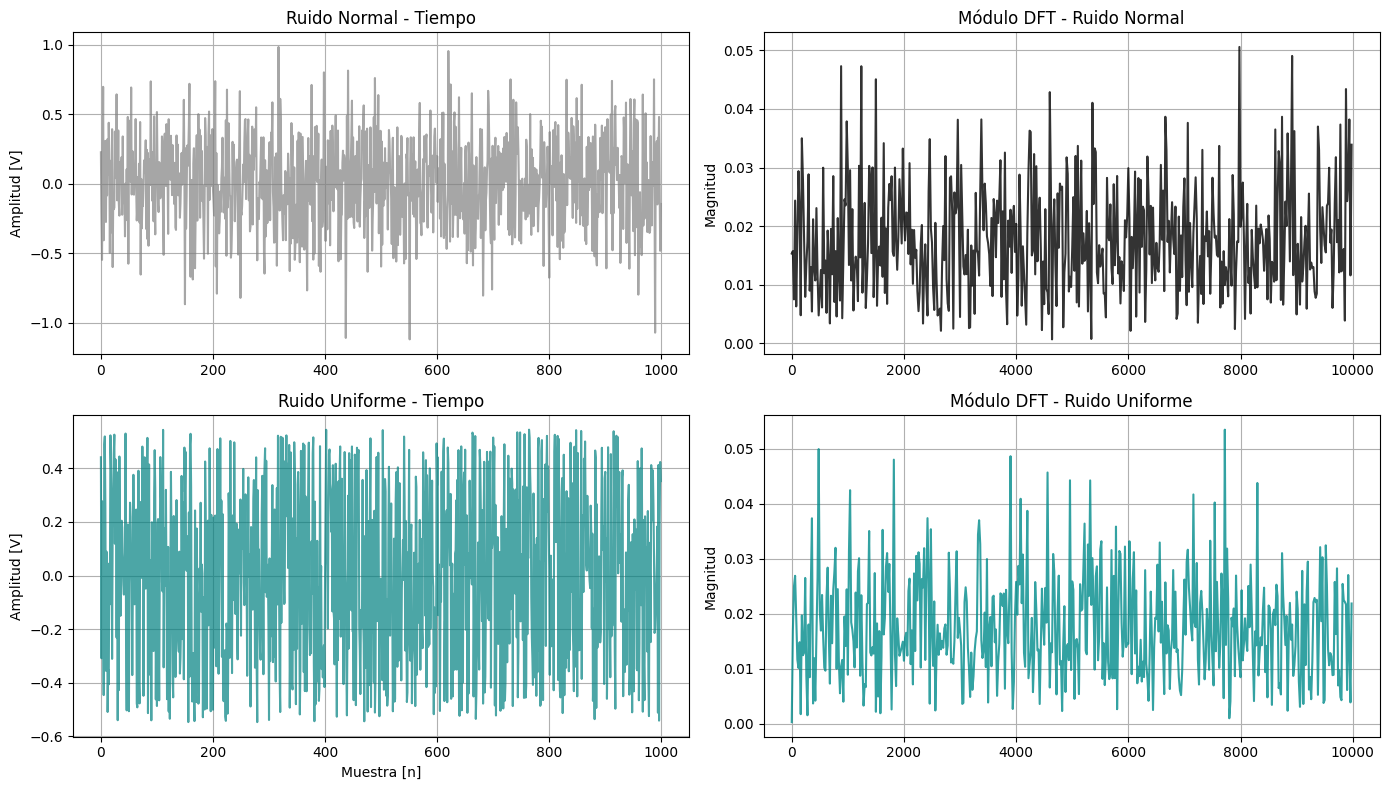

In [5]:
varianza = 0.1
desv_est = np.sqrt(varianza)
a_uniforme = np.sqrt(0.3)  # a^2 / 3 = 0.1 => a = sqrt(0.3)

ruido_n = np.random.normal(loc=0, scale=desv_est, size=N)
ruido_u = np.random.uniform(-a_uniforme, a_uniforme, N)

fft_rn = (2 / N) * np.fft.fft(ruido_n)
mod_rn = np.abs(fft_rn)[:N//2]

fft_ru = (2 / N) * np.fft.fft(ruido_u)
mod_ru = np.abs(fft_ru)[:N//2]

# Gráficos Ruidos 
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
axs[0, 0].plot(n, ruido_n, color='gray', alpha=0.7)
axs[0, 0].set_title('Ruido Normal - Tiempo'); axs[0, 0].set_ylabel('Amplitud [V]'); axs[0, 0].grid(True)

axs[0, 1].plot(freqs, mod_rn, color='black', alpha=0.8)
axs[0, 1].set_title('Módulo DFT - Ruido Normal'); axs[0, 1].set_ylabel('Magnitud'); axs[0, 1].grid(True)

axs[1, 0].plot(n, ruido_u, color='teal', alpha=0.7)
axs[1, 0].set_title('Ruido Uniforme - Tiempo'); axs[1, 0].set_xlabel('Muestra [n]'); axs[1, 0].set_ylabel('Amplitud [V]'); axs[1, 0].grid(True)

axs[1, 1].plot(freqs, mod_ru, color='darkcyan', alpha=0.8)
axs[1, 1].set_title('Módulo DFT - Ruido Uniforme'); axs[1, 1].set_ylabel('Magnitud'); axs[1, 1].grid(True)
plt.tight_layout(); plt.show()

## 5. Pulso Rectangular ($1\text{ W}$, 50% de ciclo de actividad)

Sintetizamos un tren de pulsos rectangulares bipolares de $2\text{ kHz}$. Su potencia se define como $P = V_{max}^2$, por lo que para $1\text{ W}$ su amplitud pico es $1\text{ V}$. 
Su espectro presenta armónicos impares que decaen en amplitud según una envolvente $\text{sinc}$.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14388\290160981.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


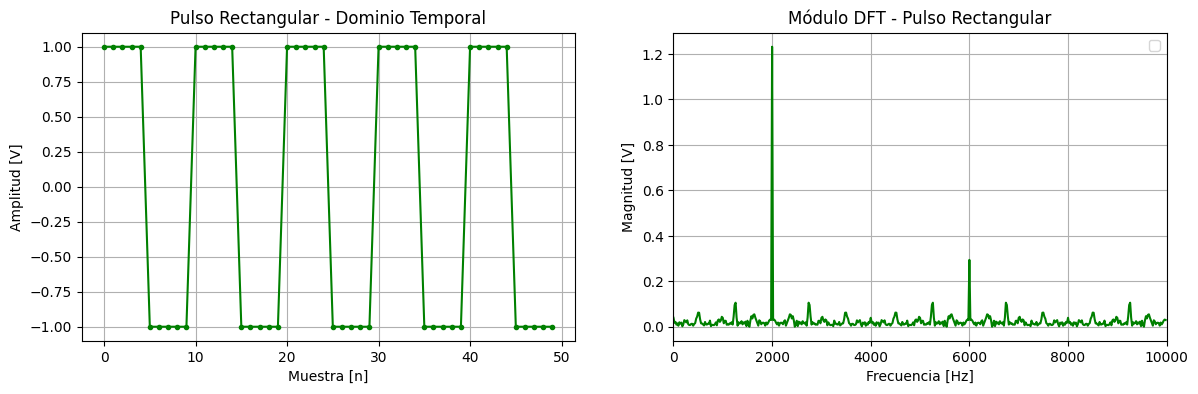

In [6]:

vmax_pulso = 1.0
pulso = vmax_pulso * signal.square(w0 * n, duty=0.5)

fft_p = (2 / N) * np.fft.fft(pulso)
mod_p = np.abs(fft_p)[:N//2]

# Gráficos Pulso
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(n[:50], pulso[:50], marker='.', color='green')
ax1.set_title('Pulso Rectangular - Dominio Temporal')
ax1.set_xlabel('Muestra [n]'); ax1.set_ylabel('Amplitud [V]'); ax1.grid(True)

ax2.plot(freqs, mod_p, color='green')
ax2.set_title('Módulo DFT - Pulso Rectangular')
ax2.set_xlabel('Frecuencia [Hz]'); ax2.set_ylabel('Magnitud [V]')
ax2.grid(True); ax2.set_xlim(0, 10000)
ax2.legend()
plt.show()

# Conclusion


El desarrollo de este trabajo práctico permitió consolidar los conceptos fundamentales de la síntesis de señales discretas y su análisis espectral a través de la Transformada Discreta de Fourier (DFT):

1. **Relación Temporal y Frecuencial:** Mediante la utilización de la frecuencia digital $\omega_0 = 2\pi \frac{f}{f_s}$, se logró una síntesis precisa y desacoplada del tiempo continuo. Al fijar una resolución espectral acorde ($\Delta f = 20\text{ Hz}$ para $f_0 = 2000\text{ Hz}$ con $N = 1000$ muestras), se garantizó que la energía de las señales sinusoidales puras se concentrara exactamente en el *bin* correspondiente ($k = 100$), evitando por completo la fuga espectral.
2. **Amplitud y la Fase:** Se comprobó que las modificaciones en la potencia media de la señal impactan de forma directa en la amplitud máxima del espectro de módulo ($V_{max} = \sqrt{2P}$). Asimismo, se verificó que los desfasajes temporales (como el de $\pi/2$ en la segunda señal) operan exclusivamente sobre la fase de la transformada, dejando el módulo completamente invariable.
3. **Señales No Determinísticas y Transiciones Abruptas:** Las secuencias de ruido (normal y uniforme) demostraron el comportamiento espectral característico del ruido blanco, distribuyendo su energía de manera difusa y uniforme a lo largo de todo el ancho de banda. Por otro lado, el pulso rectangular evidenció cómo las discontinuidades temporales exigen componentes armónicas en altas frecuencias, manifestándose en su espectro a través de armónicos impares con una envolvente típica de la función $\text{sinc}$.

